# GCC128 - Inteligência Artificial
## Trabalho Prático 01 - Classificação KNN

Implementação *hardcore* (do zero) do algoritmo K-Nearest Neighbors e comparação
com a implementação da biblioteca Scikit-learn, usando a base de dados **Iris**.

Ambas as implementações recebem exatamente os mesmos conjuntos de treino e teste,
o que torna a comparação justa.

## 1. Importações e parâmetros

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score

VALORES_K = [1, 3, 5, 7]
PROP_TREINO = 0.6
SEMENTE = 42       # fixa para garantir reprodutibilidade dos resultados
REPETICOES = 10    # execucoes por medicao de tempo (media e desvio padrao)

## 2. Carga e partição dos dados

A base Iris possui 150 amostras, 4 atributos e 3 classes. A partição é feita embaralhando os índices com a semente fixa e separando 60% para treino e 40% para teste.

In [2]:
def carregar_dados():
    base = load_iris()
    return base.data, base.target, base.target_names


def dividir_treino_teste(X, y, prop_treino, seed):
    rng = np.random.default_rng(seed)
    indices = rng.permutation(len(X))
    corte = int(len(X) * prop_treino)
    tr, te = indices[:corte], indices[corte:]
    return X[tr], y[tr], X[te], y[te]


X, y, nomes = carregar_dados()
X_tr, y_tr, X_te, y_te = dividir_treino_teste(X, y, PROP_TREINO, SEMENTE)
n_classes = len(nomes)

print(f"Base Iris: {len(X)} amostras, {X.shape[1]} atributos, {n_classes} classes")
print(f"Treino: {len(X_tr)} amostras | Teste: {len(X_te)} amostras")

Base Iris: 150 amostras, 4 atributos, 3 classes
Treino: 90 amostras | Teste: 60 amostras


## 3. Implementação *hardcore* do KNN

O algoritmo segue quatro etapas:

1. Calcular a distância euclidiana da amostra de teste até **todos** os pontos de treino
2. Ordenar as distâncias e selecionar os `k` menores
3. Aplicar o voto majoritário entre as classes desses `k` vizinhos
4. Atribuir a classe vencedora como predição

Nenhuma biblioteca de aprendizado de máquina é usada aqui — apenas NumPy para as
operações matemáticas básicas.

In [3]:
def distancia_euclidiana(a, b):
    return np.sqrt(np.sum((a - b) ** 2))


def voto_majoritario(rotulos):
    valores, contagens = np.unique(rotulos, return_counts=True)
    return valores[np.argmax(contagens)]


def knn_predizer(X_treino, y_treino, X_teste, k):
    predicoes = []
    for amostra in X_teste:
        distancias = np.array([distancia_euclidiana(amostra, t) for t in X_treino])
        vizinhos = np.argsort(distancias)[:k]
        predicoes.append(voto_majoritario(y_treino[vizinhos]))
    return np.array(predicoes)

## 4. Métricas de avaliação implementadas manualmente

- **Matriz de confusão:** posição `[i][j]` conta as amostras da classe real `i` preditas como `j`
- **Precisão** por classe: diagonal dividida pela soma das colunas
- **Revocação** por classe: diagonal dividida pela soma das linhas
- **Acurácia** (taxa de reconhecimento): total de acertos sobre total de predições

In [4]:
def matriz_confusao(y_real, y_pred, n_classes):
    matriz = np.zeros((n_classes, n_classes), dtype=int)
    for real, pred in zip(y_real, y_pred):
        matriz[real][pred] += 1
    return matriz


def calcular_metricas(matriz):
    diagonal = np.diag(matriz)
    soma_colunas = matriz.sum(axis=0)
    soma_linhas = matriz.sum(axis=1)
    precisao = np.divide(diagonal, soma_colunas,
                         out=np.zeros(len(diagonal)), where=soma_colunas != 0)
    revocacao = np.divide(diagonal, soma_linhas,
                          out=np.zeros(len(diagonal)), where=soma_linhas != 0)
    acuracia = diagonal.sum() / matriz.sum()
    return precisao, revocacao, acuracia

## 5. Medição de tempo e plotagem

O tempo de uma única execução é instável. Cada medição roda uma vez para aquecimento
(evitando o custo de importações tardias e da construção da estrutura de índice) e depois
repete 10 execuções, reportando **média ± desvio padrão**.

A matriz de confusão e as métricas são plotadas graficamente, conforme pedido no enunciado.

In [5]:
def medir(funcao, repeticoes=REPETICOES):
    """Executa uma vez para aquecimento e depois mede N repeticoes.
    Retorna media e desvio padrao em milissegundos."""
    funcao()
    tempos = []
    for _ in range(repeticoes):
        inicio = time.perf_counter()
        funcao()
        tempos.append((time.perf_counter() - inicio) * 1000)
    return float(np.mean(tempos)), float(np.std(tempos))


def plotar_avaliacao(matriz, precisao, revocacao, acuracia, nomes, k):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.6),
                                   gridspec_kw={"width_ratios": [1, 1.15]})

    im = ax1.imshow(matriz, cmap="Purples")
    ax1.set_xticks(range(len(nomes)), nomes, rotation=20)
    ax1.set_yticks(range(len(nomes)), nomes)
    ax1.set_xlabel("Classe predita")
    ax1.set_ylabel("Classe real")
    ax1.set_title(f"Matriz de confusão (k = {k})")
    limite = matriz.max() / 2
    for i in range(len(nomes)):
        for j in range(len(nomes)):
            ax1.text(j, i, matriz[i, j], ha="center", va="center",
                     color="white" if matriz[i, j] > limite else "black",
                     fontsize=13, fontweight="bold")
    fig.colorbar(im, ax=ax1, shrink=0.8)

    x = np.arange(len(nomes))
    largura = 0.38
    b1 = ax2.bar(x - largura / 2, precisao, largura, label="Precisão", color="#5B3E8E")
    b2 = ax2.bar(x + largura / 2, revocacao, largura, label="Revocação", color="#7FA88C")
    ax2.bar_label(b1, fmt="%.3f", fontsize=8, padding=2)
    ax2.bar_label(b2, fmt="%.3f", fontsize=8, padding=2)
    ax2.axhline(acuracia, color="#D99A3E", linestyle="--", linewidth=1.5,
                label=f"Acurácia geral = {acuracia:.4f}")
    ax2.set_xticks(x, nomes)
    ax2.set_ylim(0, 1.12)
    ax2.set_ylabel("Valor da métrica")
    ax2.set_title(f"Métricas de avaliação por classe (k = {k})")
    ax2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3,
               fontsize=8, frameon=False)
    ax2.spines[["top", "right"]].set_visible(False)

    fig.tight_layout()
    plt.show()

## 6. Funções de impressão

In [6]:
def imprimir_matriz(matriz, nomes):
    cabecalho = "".join(f"{n[:10]:>12}" for n in nomes)
    print(f"{'real/predito':>14}{cabecalho}")
    for i, nome in enumerate(nomes):
        linha = "".join(f"{v:>12}" for v in matriz[i])
        print(f"{nome:>14}{linha}")


def imprimir_resultado(titulo, matriz, precisao, revocacao, acuracia, nomes, media, desvio):
    print(f"\n--- {titulo} ---")
    imprimir_matriz(matriz, nomes)
    print(f"\n{'classe':>14}{'precisao':>12}{'revocacao':>12}")
    for i, nome in enumerate(nomes):
        print(f"{nome:>14}{precisao[i]:>12.4f}{revocacao[i]:>12.4f}")
    print(f"{'MEDIA':>14}{precisao.mean():>12.4f}{revocacao.mean():>12.4f}")
    print(f"Acuracia (taxa de reconhecimento): {acuracia:.4f}  ({acuracia*100:.2f}%)")
    print(f"Tempo: {media:.2f} +/- {desvio:.2f} ms (media de {REPETICOES} execucoes)")

## 7. Execução para k = {1, 3, 5, 7}

Para cada valor de k as duas implementações são executadas sobre os mesmos dados e as métricas são comparadas.


K = 1



--- IMPLEMENTACAO HARDCORE ---
  real/predito      setosa  versicolor   virginica
        setosa          23           0           0
    versicolor           0          13           1
     virginica           0           2          21

        classe    precisao   revocacao
        setosa      1.0000      1.0000
    versicolor      0.8667      0.9286
     virginica      0.9545      0.9130
         MEDIA      0.9404      0.9472
Acuracia (taxa de reconhecimento): 0.9500  (95.00%)
Tempo: 19.25 +/- 0.58 ms (media de 10 execucoes)

--- IMPLEMENTACAO SKLEARN ---
  real/predito      setosa  versicolor   virginica
        setosa          23           0           0
    versicolor           0          13           1
     virginica           0           2          21

        classe    precisao   revocacao
        setosa      1.0000      1.0000
    versicolor      0.8667      0.9286
     virginica      0.9545      0.9130
         MEDIA      0.9404      0.9472
Acuracia (taxa de reconhecimento): 0

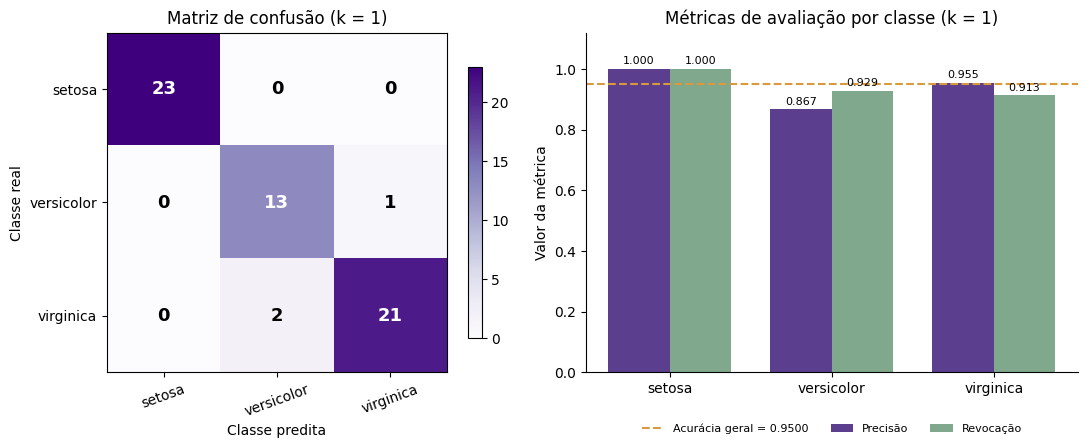


K = 3



--- IMPLEMENTACAO HARDCORE ---
  real/predito      setosa  versicolor   virginica
        setosa          23           0           0
    versicolor           0          13           1
     virginica           0           1          22

        classe    precisao   revocacao
        setosa      1.0000      1.0000
    versicolor      0.9286      0.9286
     virginica      0.9565      0.9565
         MEDIA      0.9617      0.9617
Acuracia (taxa de reconhecimento): 0.9667  (96.67%)
Tempo: 19.63 +/- 0.71 ms (media de 10 execucoes)

--- IMPLEMENTACAO SKLEARN ---
  real/predito      setosa  versicolor   virginica
        setosa          23           0           0
    versicolor           0          13           1
     virginica           0           1          22

        classe    precisao   revocacao
        setosa      1.0000      1.0000
    versicolor      0.9286      0.9286
     virginica      0.9565      0.9565
         MEDIA      0.9617      0.9617
Acuracia (taxa de reconhecimento): 0

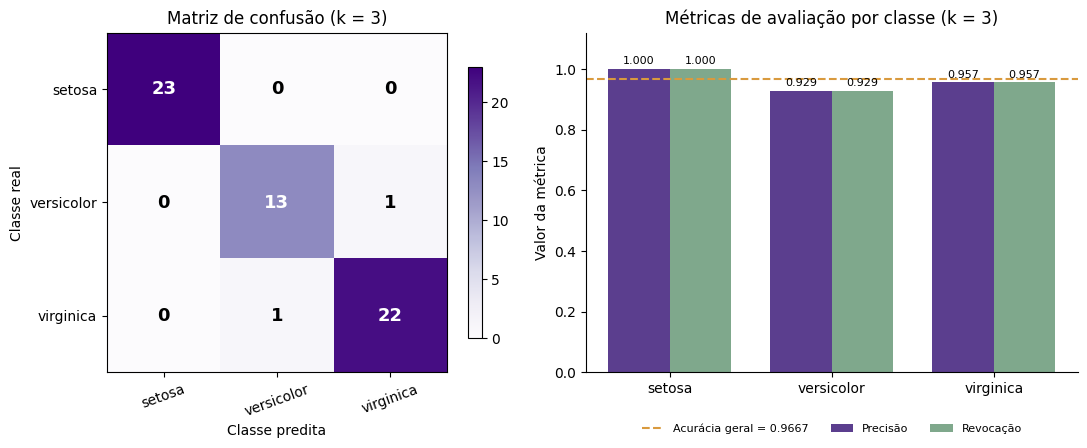


K = 5



--- IMPLEMENTACAO HARDCORE ---
  real/predito      setosa  versicolor   virginica
        setosa          23           0           0
    versicolor           0          13           1
     virginica           0           0          23

        classe    precisao   revocacao
        setosa      1.0000      1.0000
    versicolor      1.0000      0.9286
     virginica      0.9583      1.0000
         MEDIA      0.9861      0.9762
Acuracia (taxa de reconhecimento): 0.9833  (98.33%)
Tempo: 20.60 +/- 1.29 ms (media de 10 execucoes)

--- IMPLEMENTACAO SKLEARN ---
  real/predito      setosa  versicolor   virginica
        setosa          23           0           0
    versicolor           0          13           1
     virginica           0           0          23

        classe    precisao   revocacao
        setosa      1.0000      1.0000
    versicolor      1.0000      0.9286
     virginica      0.9583      1.0000
         MEDIA      0.9861      0.9762
Acuracia (taxa de reconhecimento): 0

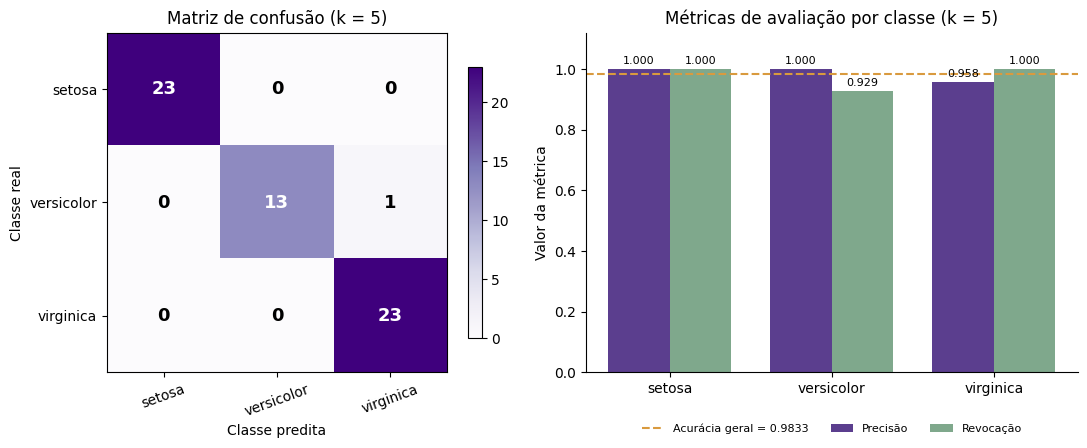


K = 7



--- IMPLEMENTACAO HARDCORE ---
  real/predito      setosa  versicolor   virginica
        setosa          23           0           0
    versicolor           0          13           1
     virginica           0           1          22

        classe    precisao   revocacao
        setosa      1.0000      1.0000
    versicolor      0.9286      0.9286
     virginica      0.9565      0.9565
         MEDIA      0.9617      0.9617
Acuracia (taxa de reconhecimento): 0.9667  (96.67%)
Tempo: 19.67 +/- 1.07 ms (media de 10 execucoes)

--- IMPLEMENTACAO SKLEARN ---
  real/predito      setosa  versicolor   virginica
        setosa          23           0           0
    versicolor           0          13           1
     virginica           0           1          22

        classe    precisao   revocacao
        setosa      1.0000      1.0000
    versicolor      0.9286      0.9286
     virginica      0.9565      0.9565
         MEDIA      0.9617      0.9617
Acuracia (taxa de reconhecimento): 0

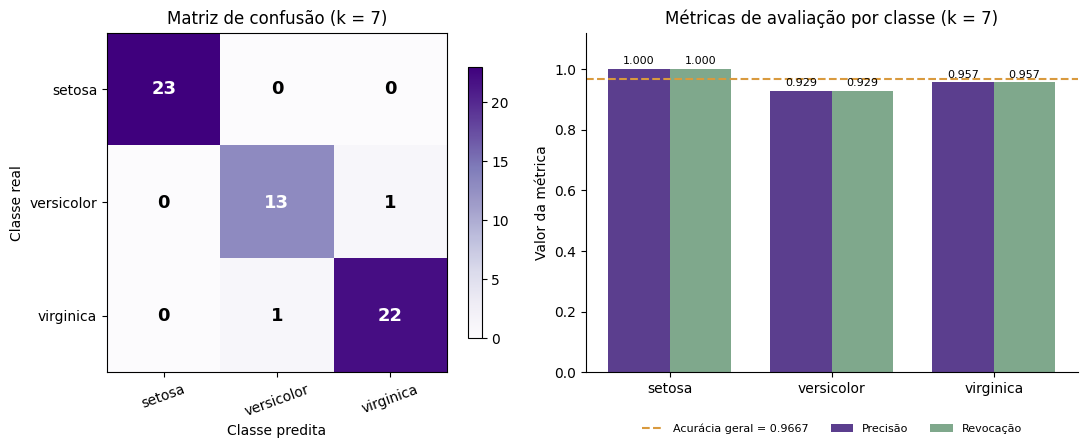

In [7]:
resumo = []

for k in VALORES_K:
    print("\n" + "=" * 62)
    print(f"K = {k}")
    print("=" * 62)

    # --- implementacao hardcore ---
    pred_hc = knn_predizer(X_tr, y_tr, X_te, k)
    m_hc, d_hc = medir(lambda: knn_predizer(X_tr, y_tr, X_te, k))
    mc_hc = matriz_confusao(y_te, pred_hc, n_classes)
    prec_hc, rev_hc, acc_hc = calcular_metricas(mc_hc)
    imprimir_resultado("IMPLEMENTACAO HARDCORE", mc_hc, prec_hc, rev_hc, acc_hc, nomes, m_hc, d_hc)

    # --- implementacao sklearn ---
    def rodar_sklearn(k=k):
        modelo = KNeighborsClassifier(n_neighbors=k)
        modelo.fit(X_tr, y_tr)
        return modelo.predict(X_te)

    pred_sk = rodar_sklearn()
    m_sk, d_sk = medir(rodar_sklearn)
    mc_sk = confusion_matrix(y_te, pred_sk)
    prec_sk = precision_score(y_te, pred_sk, average=None, zero_division=0)
    rev_sk = recall_score(y_te, pred_sk, average=None, zero_division=0)
    acc_sk = accuracy_score(y_te, pred_sk)
    imprimir_resultado("IMPLEMENTACAO SKLEARN", mc_sk, prec_sk, rev_sk, acc_sk, nomes, m_sk, d_sk)

    divergencias = int(np.sum(pred_hc != pred_sk))
    print(f"\nPredicoes divergentes entre as duas implementacoes: {divergencias}/{len(y_te)}")

    plotar_avaliacao(mc_hc, prec_hc, rev_hc, acc_hc, nomes, k)
    resumo.append((k, acc_hc, acc_sk, m_hc, d_hc, m_sk, d_sk, divergencias))

## 8. Resumo comparativo

In [8]:
print(f"{'k':>3}{'acc hardcore':>15}{'acc sklearn':>14}"
      f"{'t hardcore (ms)':>20}{'t sklearn (ms)':>18}{'razao':>8}{'difs':>7}")
for k, a_hc, a_sk, m_hc, d_hc, m_sk, d_sk, dv in resumo:
    print(f"{k:>3}{a_hc:>15.4f}{a_sk:>14.4f}"
          f"{m_hc:>13.2f} ± {d_hc:<4.2f}{m_sk:>11.2f} ± {d_sk:<4.2f}"
          f"{m_hc/m_sk:>7.1f}x{dv:>7}")
print(f"\nTempos: media ± desvio padrao de {REPETICOES} execucoes, apos aquecimento.")

modelo = KNeighborsClassifier(n_neighbors=5).fit(X_tr, y_tr)
print(f"Estrutura selecionada pelo Sklearn (algorithm='auto'): {modelo._fit_method}")

  k   acc hardcore   acc sklearn     t hardcore (ms)    t sklearn (ms)   razao   difs
  1         0.9500        0.9500        19.25 ± 0.58       1.43 ± 0.08   13.4x      0
  3         0.9667        0.9667        19.63 ± 0.71       1.48 ± 0.07   13.3x      0
  5         0.9833        0.9833        20.60 ± 1.29       1.46 ± 0.05   14.1x      0
  7         0.9667        0.9667        19.67 ± 1.07       1.52 ± 0.08   12.9x      0

Tempos: media ± desvio padrao de 10 execucoes, apos aquecimento.
Estrutura selecionada pelo Sklearn (algorithm='auto'): kd_tree


## 9. Impacto do tamanho da base de aprendizagem

Variando a proporção de treino com k fixo em 3, observa-se como o volume de dados rotulados afeta a taxa de reconhecimento.

In [9]:
print(f"{'% treino':>10}{'n treino':>10}{'acuracia':>12}")
for prop in [0.2, 0.4, 0.6, 0.8]:
    Xa, ya, Xb, yb = dividir_treino_teste(X, y, prop, SEMENTE)
    pred = knn_predizer(Xa, ya, Xb, 3)
    _, _, acc = calcular_metricas(matriz_confusao(yb, pred, n_classes))
    print(f"{prop*100:>9.0f}%{len(Xa):>10}{acc:>12.4f}")

  % treino  n treino    acuracia
       20%        30      0.9250
       40%        60      0.9778
       60%        90      0.9667
       80%       120      1.0000


## 10. Conclusão

As duas implementações produziram **matrizes de confusão e métricas idênticas** em todos
os valores de k testados, com zero predições divergentes. Isso valida a corretude da
implementação *hardcore*. Vale notar que ambas resolvem eventuais empates no voto
majoritário pelo menor rótulo de classe, o que contribui para essa convergência.

A diferença está no desempenho. Nas medições realizadas — média de 10 execuções após
aquecimento — a versão do Scikit-learn foi consistentemente mais rápida, por volta de uma
ordem de grandeza. A implementação própria calcula as distâncias em laço explícito, com custo
O(n·m) por predição, enquanto a biblioteca usa código vetorizado compilado e uma estrutura de
índice espacial. Com `algorithm='auto'` o Scikit-learn selecionou a KD-Tree neste conjunto de
dados, mas essa escolha é automática e depende das características dos dados e da versão da
biblioteca. Como tempos de execução variam com o ambiente, a comparação deve ser lida como
uma ordem de grandeza, não como um fator exato.

Quanto ao valor de k, k=5 obteve a melhor taxa de reconhecimento. A classe *setosa* foi
classificada perfeitamente em todos os casos por ser linearmente separável, enquanto os
erros se concentraram entre *versicolor* e *virginica*, cujas amostras se sobrepõem no
espaço de atributos.